# Addestramento CNN per implementazione su FPGA

**Install/import e seed**


In [1]:
import os
import json
import math
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

# Seed per riproducibilità
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.20.0


**Configurazione del progetto**

In [2]:
# Parametri globali del progetto
IMG_H = 14
IMG_W = 14
IMG_C = 1
NUM_CLASSES = 10

BATCH_SIZE = 128
EPOCHS = 8

# Quantizzazione fixed-point per FPGA
# Useremo int8 con scala per layer
Q_BITS = 8
Q_MAX = 127
Q_MIN = -127

PROJECT_DIR = "/content/fpga_mnist_tf"
os.makedirs(PROJECT_DIR, exist_ok=True)

MODEL_PATH = os.path.join(PROJECT_DIR, "mnist_cnn_fpga.keras")
WEIGHTS_NPZ_PATH = os.path.join(PROJECT_DIR, "mnist_cnn_fpga_weights.npz")
HEADER_PATH = os.path.join(PROJECT_DIR, "weights_fpga.h")
TEST_SAMPLES_PATH = os.path.join(PROJECT_DIR, "test_samples.npz")

print("Project dir:", PROJECT_DIR)

Project dir: /content/fpga_mnist_tf


**Download e preprocessing MNIST**

In [3]:
# Download MNIST da Keras datasets
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Original train shape:", x_train.shape)
print("Original test shape :", x_test.shape)

# Normalizzazione in [0,1]
x_train = x_train.astype(np.float32) / 255.0
x_test  = x_test.astype(np.float32) / 255.0

# Aggiungiamo il canale
x_train = np.expand_dims(x_train, axis=-1)  # (N,28,28,1)
x_test  = np.expand_dims(x_test, axis=-1)

print("After channel expand:", x_train.shape, x_test.shape)

# Ridimensionamento a 14x14
x_train_resized = tf.image.resize(x_train, [IMG_H, IMG_W], method="bilinear").numpy()
x_test_resized  = tf.image.resize(x_test,  [IMG_H, IMG_W], method="bilinear").numpy()

print("Resized train shape:", x_train_resized.shape)
print("Resized test shape :", x_test_resized.shape)

# Salviamo anche alcuni sample di test per uso futuro
num_test_samples_to_save = 100
np.savez(
    TEST_SAMPLES_PATH,
    images=x_test_resized[:num_test_samples_to_save],
    labels=y_test[:num_test_samples_to_save]
)

print("Saved test samples to:", TEST_SAMPLES_PATH)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Original train shape: (60000, 28, 28)
Original test shape : (10000, 28, 28)
After channel expand: (60000, 28, 28, 1) (10000, 28, 28, 1)
Resized train shape: (60000, 14, 14, 1)
Resized test shape : (10000, 14, 14, 1)
Saved test samples to: /content/fpga_mnist_tf/test_samples.npz


**Visualizzazione rapida**

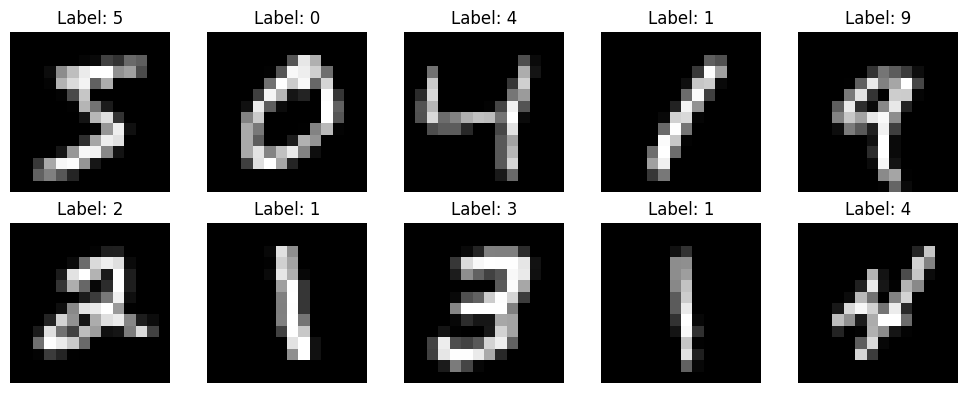

In [4]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train_resized[i, :, :, 0], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

**Definizione della CNN**

In [5]:
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(IMG_H, IMG_W, IMG_C)),

        layers.Conv2D(
            filters=4,
            kernel_size=(3, 3),
            padding="same",
            activation="relu",
            name="conv1"
        ),
        layers.MaxPooling2D(pool_size=(2, 2), name="pool1"),

        layers.Conv2D(
            filters=8,
            kernel_size=(3, 3),
            padding="same",
            activation="relu",
            name="conv2"
        ),
        layers.MaxPooling2D(pool_size=(2, 2), name="pool2"),

        layers.Flatten(name="flatten"),
        layers.Dense(16, activation="relu", name="fc1"),
        layers.Dense(NUM_CLASSES, activation=None, name="fc2")
    ])

    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 14, 14, 4)      │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 7, 7, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 7, 7, 8)        │           296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 3, 3, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 72)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 16)             │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,674 (6.54 KB)

 Trainable params: 1,674 (6.54 KB)

 Non-trainable params: 0 (0.00 B)

**Compilazione e training**

In [6]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

history = model.fit(
    x_train_resized,
    y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6143 - loss: 1.1963 - val_accuracy: 0.9022 - val_loss: 0.3598
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9040 - loss: 0.3308 - val_accuracy: 0.9398 - val_loss: 0.2116
Epoch 3/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9293 - loss: 0.2398 - val_accuracy: 0.9490 - val_loss: 0.1700
Epoch 4/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9400 - loss: 0.2009 - val_accuracy: 0.9575 - val_loss: 0.1498
Epoch 5/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9462 - loss: 0.1781 - val_accuracy: 0.9607 - val_loss: 0.1370
Epoch 6/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9509 - loss: 0.1630 - val_accuracy: 0.9635 - val_loss: 0.1271
Epoch 7/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9544 - loss: 0.1519 - val_accuracy: 0.9665 - val_loss: 0.1201
Epoch 8/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9568 - loss: 0.1435 - val_accuracy: 0.9683

**Valutazione finale**

In [7]:
test_loss, test_acc = model.evaluate(x_test_resized, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss    : {test_loss:.4f}")

Test accuracy: 0.9613
Test loss    : 0.1237


**Salvataggio modello**

In [8]:
model.save(MODEL_PATH)
print("Saved model to:", MODEL_PATH)

Saved model to: /content/fpga_mnist_tf/mnist_cnn_fpga.keras


**Estrazione pesi floating-point**

In [9]:
weights_dict = {}

for layer in model.layers:
    params = layer.get_weights()
    if len(params) == 0:
        continue

    print(f"\nLayer: {layer.name}")
    for idx, p in enumerate(params):
        print(f"  Param {idx} shape = {p.shape}")
        weights_dict[f"{layer.name}_{idx}"] = p

np.savez(WEIGHTS_NPZ_PATH, **weights_dict)
print("\nSaved floating weights to:", WEIGHTS_NPZ_PATH)


Layer: conv1
  Param 0 shape = (3, 3, 1, 4)
  Param 1 shape = (4,)

Layer: conv2
  Param 0 shape = (3, 3, 4, 8)
  Param 1 shape = (8,)

Layer: fc1
  Param 0 shape = (72, 16)
  Param 1 shape = (16,)

Layer: fc2
  Param 0 shape = (16, 10)
  Param 1 shape = (10,)

Saved floating weights to: /content/fpga_mnist_tf/mnist_cnn_fpga_weights.npz


**Funzioni di quantizzazione**

In [10]:
# ============================================================
# Nuove funzioni di quantizzazione per HLS
# ============================================================

WEIGHT_SCALE = 128      # Q1.7
BIAS_SCALE   = 32768    # per bias compatibili con accumuli int32

def quantize_w_q7(x):
    """
    Quantizza i pesi in int8 con scala 128 (Q1.7)
    """
    xq = np.round(x * WEIGHT_SCALE)
    xq = np.clip(xq, -127, 127).astype(np.int8)
    return xq

def quantize_b_q15(x):
    """
    Quantizza i bias in int32 con scala 32768
    """
    xq = np.round(x * BIAS_SCALE).astype(np.int32)
    return xq

# Recupero diretto dei layer dal modello
layer_conv1 = model.get_layer("conv1")
layer_conv2 = model.get_layer("conv2")
layer_fc1   = model.get_layer("fc1")
layer_fc2   = model.get_layer("fc2")

# Pesi floating-point dal modello TensorFlow
conv1_w_f, conv1_b_f = layer_conv1.get_weights()
conv2_w_f, conv2_b_f = layer_conv2.get_weights()
fc1_w_f,   fc1_b_f   = layer_fc1.get_weights()
fc2_w_f,   fc2_b_f   = layer_fc2.get_weights()

# Quantizzazione
conv1_w_q = quantize_w_q7(conv1_w_f)
conv1_b_q = quantize_b_q15(conv1_b_f)

conv2_w_q = quantize_w_q7(conv2_w_f)
conv2_b_q = quantize_b_q15(conv2_b_f)

fc1_w_q = quantize_w_q7(fc1_w_f)
fc1_b_q = quantize_b_q15(fc1_b_f)

fc2_w_q = quantize_w_q7(fc2_w_f)
fc2_b_q = quantize_b_q15(fc2_b_f)

# Controllo shape
print("conv1_w shape:", conv1_w_q.shape)   # atteso: (3, 3, 1, 4)
print("conv1_b shape:", conv1_b_q.shape)   # atteso: (4,)

print("conv2_w shape:", conv2_w_q.shape)   # atteso: (3, 3, 4, 8)
print("conv2_b shape:", conv2_b_q.shape)   # atteso: (8,)

print("fc1_w shape  :", fc1_w_q.shape)     # atteso: (72, 16)
print("fc1_b shape  :", fc1_b_q.shape)     # atteso: (16,)

print("fc2_w shape  :", fc2_w_q.shape)     # atteso: (16, 10)
print("fc2_b shape  :", fc2_b_q.shape)     # atteso: (10,)

# Range di controllo
print("\nRange quantizzati:")
print("conv1_w:", conv1_w_q.min(), conv1_w_q.max())
print("conv2_w:", conv2_w_q.min(), conv2_w_q.max())
print("fc1_w  :", fc1_w_q.min(), fc1_w_q.max())
print("fc2_w  :", fc2_w_q.min(), fc2_w_q.max())

conv1_w shape: (3, 3, 1, 4)
conv1_b shape: (4,)
conv2_w shape: (3, 3, 4, 8)
conv2_b shape: (8,)
fc1_w shape  : (72, 16)
fc1_b shape  : (16,)
fc2_w shape  : (16, 10)
fc2_b shape  : (10,)

Range quantizzati:
conv1_w: -127 112
conv2_w: -127 112
fc1_w  : -113 127
fc2_w  : -127 94


**Esportazione header C/H per HLS**

In [11]:
# ============================================================
# Nuova esportazione header C/H per HLS
# ============================================================

def c_array_shape(shape):
    return "".join([f"[{d}]" for d in shape])

def write_c_array(f, ctype, name, arr):
    flat = arr.flatten()
    f.write(f"static const {ctype} {name}{c_array_shape(arr.shape)} = {{\n")
    values_per_line = 16
    for i in range(0, len(flat), values_per_line):
        chunk = flat[i:i+values_per_line]
        line = ", ".join(str(int(v)) for v in chunk)
        f.write("    " + line)
        if i + values_per_line < len(flat):
            f.write(",")
        f.write("\n")
    f.write("};\n\n")

with open(HEADER_PATH, "w") as f:
    f.write("#ifndef WEIGHTS_FPGA_H\n")
    f.write("#define WEIGHTS_FPGA_H\n\n")
    f.write("#include <stdint.h>\n\n")

    f.write("// Quantized weights generated from TensorFlow model\n")
    f.write("// Weight format: int8, scale = 128 (Q1.7)\n")
    f.write("// Bias format  : int32, scale = 32768\n\n")

    f.write("static const int WEIGHT_SHIFT = 7;\n")
    f.write("static const int WEIGHT_SCALE = 128;\n")
    f.write("static const int BIAS_SCALE = 32768;\n\n")

    # Conv1
    # TensorFlow Conv2D layout: [KH][KW][Cin][Cout]
    write_c_array(f, "int8_t",  "conv1_w", conv1_w_q)
    write_c_array(f, "int32_t", "conv1_b", conv1_b_q)

    # Conv2
    write_c_array(f, "int8_t",  "conv2_w", conv2_w_q)
    write_c_array(f, "int32_t", "conv2_b", conv2_b_q)

    # FC1
    # TensorFlow Dense layout: [IN][OUT]
    write_c_array(f, "int8_t",  "fc1_w", fc1_w_q)
    write_c_array(f, "int32_t", "fc1_b", fc1_b_q)

    # FC2
    write_c_array(f, "int8_t",  "fc2_w", fc2_w_q)
    write_c_array(f, "int32_t", "fc2_b", fc2_b_q)

    f.write("#endif\n")

print("Generated header:", HEADER_PATH)

Generated header: /content/fpga_mnist_tf/weights_fpga.h


**Test rapido di inferenza software**

In [12]:
logits = model.predict(x_test_resized[:20], verbose=0)
preds = np.argmax(logits, axis=1)

for i in range(20):
    print(f"Sample {i:02d} | GT={y_test[i]} | PRED={preds[i]}")

Sample 00 | GT=7 | PRED=7
Sample 01 | GT=2 | PRED=2
Sample 02 | GT=1 | PRED=1
Sample 03 | GT=0 | PRED=0
Sample 04 | GT=4 | PRED=4
Sample 05 | GT=1 | PRED=1
Sample 06 | GT=4 | PRED=4
Sample 07 | GT=9 | PRED=9
Sample 08 | GT=5 | PRED=5
Sample 09 | GT=9 | PRED=9
Sample 10 | GT=0 | PRED=0
Sample 11 | GT=6 | PRED=6
Sample 12 | GT=9 | PRED=9
Sample 13 | GT=0 | PRED=0
Sample 14 | GT=1 | PRED=1
Sample 15 | GT=5 | PRED=5
Sample 16 | GT=9 | PRED=9
Sample 17 | GT=7 | PRED=7
Sample 18 | GT=3 | PRED=3
Sample 19 | GT=4 | PRED=4


**Download** dei file dal Colab

In [13]:
from google.colab import files

files.download(MODEL_PATH)
files.download(WEIGHTS_NPZ_PATH)
files.download(HEADER_PATH)
files.download(TEST_SAMPLES_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>